In [1]:
import numpy as np
import pandas as pd

# =====================
# Plotting
# =====================
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
import seaborn as sns

# =====================
# SciPy / Stats
# =====================
from scipy.stats import norm
import statsmodels.api as sm
import statsmodels.formula.api as smf

# =====================
# sklearn – model selection
# =====================
from sklearn.model_selection import train_test_split

# =====================
# sklearn – models
# =====================
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# =====================
# sklearn – metrics
# =====================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    r2_score,
    mean_squared_error,
)

# =====================
# Utilities
# =====================
from itertools import combinations, product
from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import matplotlib as mpl
from matplotlib.patches import Patch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, ListedColormap, BoundaryNorm
from matplotlib.patches import Patch



# Some auxiliary functions

In [2]:
# Construct the replicator model
def construct_replicator_features(X):
    linear_part = X.values  # shape: [n_samples, 11]

    # Cross-species interactions only (i < j)
    cross_terms = []
    for i, j in combinations(range(X.shape[1]), 2):
        interaction = - (X.iloc[:, i] * X.iloc[:, j]).values.reshape(-1, 1)
        cross_terms.append(interaction)

    quadratic_part = np.hstack(cross_terms)  # shape: [n_samples, 55]
    features = np.hstack([linear_part, quadratic_part])  # shape: [n_samples, 66]
    return features

# Take the mid point of each Nugent score class. Easier to multiply it by 10 here and divide later
def convert_to_levels(y):
    return pd.cut(
        y,
        bins=[-0.1, 3, 6, 10],  # 3 categories
        labels=[15, 50, 85]     # Midpoints
    ).astype(int)

# Nugent Score transformation
def transform_y(y, N0=None, c=None):
    if N0 is None or c is None:
        return y
    N_max = 10
    d = N_max - 2 * N0 + c
    return np.log(N0 + d) - np.log(N_max - y + c)
import matplotlib.pyplot as plt


#Summarize metrics
def summarize_metrics(metrics_dict, name):
    print(f"\n{name} Average Metrics over {N} runs:")
    for key, values in metrics_dict.items():
        print(f"{key.capitalize():<10}: {np.mean(values):.4f} ± {np.std(values):.4f}")

# Importing the data

In [3]:
import pandas as pd

data = pd.read_csv(
    "14_taxa_data.csv"
)

# Response and raw taxonomic abundances
y = data.iloc[:, 3].astype(int)
X_raw = data.iloc[:, 4:]


def group_phyla_separating_lactobacilli(X):
    """
    Group taxonomic abundance columns at the phylum level, while keeping
    four Lactobacillus species as separate features.

    Outputs:
        Lactobacillus_iners
        Lactobacillus_crispatus
        Lactobacillus_jensenii
        Lactobacillus_gasseri
        Bacillota_I_other
        all other phyla
    """

    separated_lactobacilli = {
        "lactobacillus iners": "Lactobacillus_iners",
        "lactobacillus crispatus": "Lactobacillus_crispatus",
        "lactobacillus jensenii": "Lactobacillus_jensenii",
        "lactobacillus gasseri": "Lactobacillus_gasseri",
    }

    grouped_columns = {}

    for column in X.columns:
        taxonomy = str(column).split(";")

        # Extract names without prefixes such as p__ and s__
        ranks = {}

        for component in taxonomy:
            component = component.strip()

            if "__" in component:
                prefix, name = component.split("__", 1)
                ranks[prefix] = name.strip()

        phylum = ranks.get("p")
        species = ranks.get("s")

        # Skip features without a valid phylum assignment
        if not phylum or phylum.lower() in {
            "unassigned",
            "unclassified",
            "unknown",
        }:
            continue

        species_normalized = species.lower() if species else None

        # Keep the four selected Lactobacillus species separate
        if species_normalized in separated_lactobacilli:
            new_name = separated_lactobacilli[species_normalized]

        # Group the remainder of Bacillota_I
        elif phylum == "Bacillota_I":
            new_name = "Bacillota_I_other"

        # Group all other taxa at the phylum level
        else:
            new_name = phylum

        grouped_columns.setdefault(new_name, []).append(column)

    # Sum all original columns assigned to each new feature
    X_grouped = pd.DataFrame(
        {
            group_name: X[columns].sum(axis=1)
            for group_name, columns in grouped_columns.items()
        },
        index=X.index,
    )

    return X_grouped


X_grouped = group_phyla_separating_lactobacilli(X_raw)

feature_names = [
    "Actinomycetota",
    "Bacillota_A_368345",
    "Bacillota_C",
    "Bacillota_I_other",
    "Lactobacillus_iners",
    "Lactobacillus_crispatus",
    "Lactobacillus_jensenii",
    "Lactobacillus_gasseri",
    "Bacteroidota",
    "Campylobacterota_A",
    "Fusobacteriota",
    "Patescibacteria",
    "Pseudomonadota",
    "Synergistota",
]

missing = [
    name
    for name in feature_names
    if name not in X_grouped.columns
]

unexpected = [
    name
    for name in X_grouped.columns
    if name not in feature_names
]

if missing:
    raise ValueError(
        f"Expected features missing from grouped data: {missing}"
    )

if unexpected:
    print(
        "Grouped features not included in feature_names: "
        f"{unexpected}"
    )

X_grouped = X_grouped[feature_names]

row_totals = X_grouped.sum(axis=1)

X_freq = X_grouped.div(
    row_totals.replace(0, pd.NA),
    axis=0,
)

print(X_freq.columns.tolist())

['Actinomycetota', 'Bacillota_A_368345', 'Bacillota_C', 'Bacillota_I_other', 'Lactobacillus_iners', 'Lactobacillus_crispatus', 'Lactobacillus_jensenii', 'Lactobacillus_gasseri', 'Bacteroidota', 'Campylobacterota_A', 'Fusobacteriota', 'Patescibacteria', 'Pseudomonadota', 'Synergistota']


In [4]:
X_freq

,Actinomycetota,Bacillota_A_368345,Bacillota_C,Bacillota_I_other,Lactobacillus_iners,Lactobacillus_crispatus,Lactobacillus_jensenii,Lactobacillus_gasseri,Bacteroidota,Campylobacterota_A,Fusobacteriota,Patescibacteria,Pseudomonadota,Synergistota
0,0.000000,0.000880,0.000000,0.000000,0.085312,0.913808,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0
1,0.000000,0.000000,0.000000,0.002974,0.000000,0.000000,0.101115,0.895911,0.000000,0.0,0.000000,0.0,0.000000,0.0
2,0.003745,0.001498,0.000000,0.001498,0.747566,0.000000,0.245693,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0
3,0.000000,0.001360,0.000000,0.000000,0.000000,0.998640,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0
4,0.058221,0.039028,0.336532,0.031990,0.055662,0.001280,0.000000,0.000000,0.292386,0.0,0.184901,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
389,0.085997,0.003486,0.004067,0.065078,0.764672,0.000000,0.000000,0.000000,0.076700,0.0,0.000000,0.0,0.000000,0.0
390,0.000000,0.000000,0.000000,0.007922,0.766606,0.000000,0.216332,0.000000,0.009141,0.0,0.000000,0.0,0.000000,0.0
391,0.000000,0.001330,0.000000,0.615027,0.000000,0.375665,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.007979,0.0
392,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0


# Figure 2

In [5]:
def fit_transformed_ridge_on_full_data(X, y, N0=None, c=None, alpha=1.0, n_boot=1000, random_state=None, feature_names = feature_names):
    if random_state:
        np.random.seed(random_state)
    
    # Transform y
    y_transformed = transform_y(y / 10, N0, c)

    # Replicator features
    X_rep = construct_replicator_features(X)

    # Build feature names
    base_names = feature_names
    
    if X.shape[1] > len(base_names):
        base_names += [f"x{i}" for i in range(len(base_names), X.shape[1])]

    interaction_names = [
        f"{base_names[i]} * {base_names[j]}"
        for i, j in combinations(range(X.shape[1]), 2)
    ]
    feature_names = base_names + interaction_names

    # Fit Ridge regression
    model = Ridge(alpha=alpha, fit_intercept=False)
    model.fit(X_rep, y_transformed)
    r2 = model.score(X_rep, y_transformed)

    # Collect coefficients
    model_params_df = pd.DataFrame([model.coef_], columns=feature_names)


    return model_params_df, model, r2

def fit_transformed_ridge_on_full_data(
    X, y, N0=None, c=None, alpha=1.0, n_boot=1000, random_state=None, feature_name = feature_names
):
    if random_state is not None:
        np.random.seed(random_state)

    # Ensure arrays for internal use (but keep original types for nicer indexing if you want)
    X_is_df = isinstance(X, pd.DataFrame)
    y_is_series = isinstance(y, pd.Series)

    # Transform y
    y_transformed = transform_y((y / 10), N0, c)

    # Replicator features (apply to full X)
    X_rep = construct_replicator_features(X)

    # Build feature names
    base_names = feature_name
    
    if X.shape[1] > len(base_names):
        base_names += [f"x{i}" for i in range(len(base_names), X.shape[1])]

    interaction_names = [
        f"{base_names[i]} * {base_names[j]}"
        for i, j in combinations(range(X.shape[1]), 2)
    ]
    feature_names = base_names + interaction_names

    # Fit Ridge on full data
    model = Ridge(alpha=alpha, fit_intercept=False)
    model.fit(X_rep, y_transformed)
    r2 = model.score(X_rep, y_transformed)
    coef_full = model.coef_.copy()

    # Prepare bootstrap storage
    n_samples = X.shape[0]
    p = len(feature_names)
    boot_coefs = np.zeros((n_boot, p))

    # Bootstrap loop (use .iloc for DataFrame row sampling)
    for b in range(n_boot):
        idx = np.random.choice(n_samples, n_samples, replace=True)
        Xb = X.iloc[idx] if X_is_df else X[idx]
        yb = y.iloc[idx] if y_is_series else y[idx]

        yb_transformed = transform_y((yb / 10), N0, c)
        Xb_rep = construct_replicator_features(Xb)

        boot_model = Ridge(alpha=alpha, fit_intercept=False)
        boot_model.fit(Xb_rep, yb_transformed)
        boot_coefs[b, :] = boot_model.coef_

    # Bootstrap summaries
    boot_mean = np.mean(boot_coefs, axis=0)
    boot_std = np.std(boot_coefs, axis=0, ddof=1)

    # 95% percentile confidence intervals
    ci_lower = np.percentile(boot_coefs, 2.5, axis=0)
    ci_upper = np.percentile(boot_coefs, 97.5, axis=0)


    # Assemble results DataFrame
    results_df = pd.DataFrame({
        "coef": coef_full,
        "boot_mean": boot_mean,
        "boot_std": boot_std,
        "ci_lower_95": ci_lower,
        "ci_upper_95": ci_upper
    }, index=feature_names)

    return results_df, model, r2

In [6]:
y_levels = convert_to_levels(y)

N0 = 4.5
c=4

results_df, model, r2 = fit_transformed_ridge_on_full_data(
    X_freq, y_levels, N0=N0, c=c, alpha = 0.05, feature_name = feature_names
)

In [7]:
r2

0.7750950960091018

[Text(0.5, 0, 'Actinomycetota'),
 Text(1.5, 0, 'Bacillota_A_368345'),
 Text(2.5, 0, 'Bacillota_C'),
 Text(3.5, 0, 'Bacillota_I_other'),
 Text(4.5, 0, 'Lactobacillus_iners'),
 Text(5.5, 0, 'Lactobacillus_crispatus'),
 Text(6.5, 0, 'Lactobacillus_jensenii'),
 Text(7.5, 0, 'Lactobacillus_gasseri'),
 Text(8.5, 0, 'Bacteroidota'),
 Text(9.5, 0, 'Campylobacterota_A'),
 Text(10.5, 0, 'Fusobacteriota'),
 Text(11.5, 0, 'Patescibacteria'),
 Text(12.5, 0, 'Pseudomonadota'),
 Text(13.5, 0, 'Synergistota')]

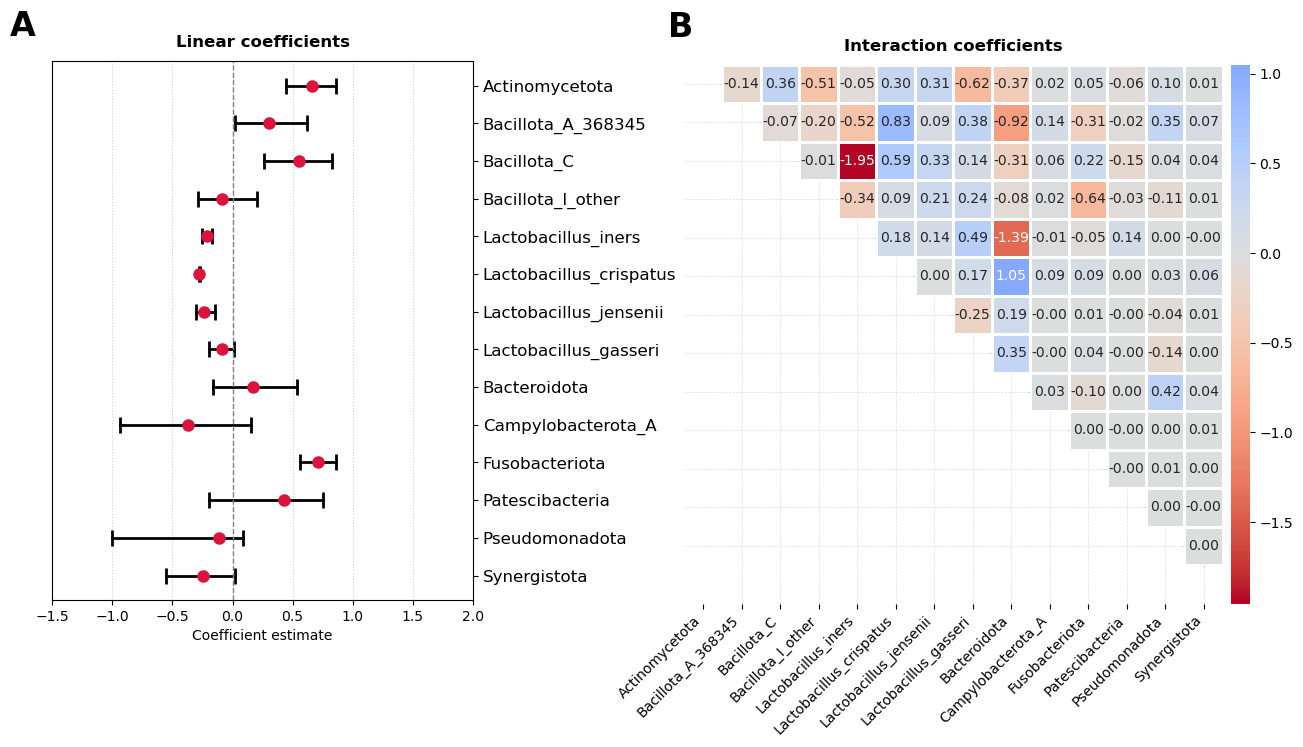

In [8]:
def plot_coefficients_ridge_ax(
    ax,
    coefs,
    ci_lower,
    ci_upper,
    feature_names,
    title=None,
):
    coefs = np.asarray(coefs)
    ci_lower = np.asarray(ci_lower)
    ci_upper = np.asarray(ci_upper)

    n = len(feature_names)

    # Reverse order so Actinomycetota is on top
    y_positions = np.arange(n)[::-1]

    for y, coef, lower, upper in zip(
        y_positions, coefs, ci_lower, ci_upper
    ):
        ax.plot([lower, upper], [y, y], color="black", lw=2)
        ax.plot(lower, y, "|", color="black", markersize=12, markeredgewidth=2)
        ax.plot(upper, y, "|", color="black", markersize=12, markeredgewidth=2)
        ax.plot(coef, y, "o", color="crimson", markersize=8)

    ax.axvline(0, color="gray", linestyle="--", lw=1)

    ax.set_yticks(y_positions)
    ax.set_yticklabels(feature_names, fontsize=12)
    
    # Move the taxon labels to the right
    ax.yaxis.tick_right()
    ax.tick_params(
        axis="y",
        labelright=True,
        labelleft=False,
    )
    ax.set_xlabel("Coefficient estimate")

    if title is not None:
        ax.set_title(title, fontweight="bold", pad=10)

    ax.grid(axis="x", linestyle=":", alpha=0.6)

def plot_interaction_heatmaps_single_fit_ax(
    results_df,
    custom_labels,
    ax,
    cbar_ax=None,
):
    n_vars = len(custom_labels)

    interaction_df = results_df.iloc[n_vars:]
    interaction_coefs = interaction_df["coef"].values

    coef_matrix = np.full((n_vars, n_vars), np.nan)

    for k, (i, j) in enumerate(combinations(range(n_vars), 2)):
        if k < len(interaction_coefs):
            coef_matrix[i, j] = interaction_coefs[k]

    mask = np.tril(np.ones_like(coef_matrix, dtype=bool), k=0)

    sns.heatmap(
        coef_matrix,
        mask=mask,
        cmap="coolwarm_r",
        center=0,
        xticklabels=custom_labels,
        yticklabels=custom_labels,
        annot=True,
        fmt=".2f",
        linewidths=0.8,
        square=True,
        ax=ax,
        cbar=True,
        cbar_ax=cbar_ax
        #cbar_kws={"label": "Coefficient"},
    )
    # Very faint guide lines through the masked region
    guide_kwargs = dict(
        color="black",
        linewidth=0.5,
        alpha=0.12,
        zorder=3,
        clip_on=True,
    )
    
    touch_length = 0.06
    
    # Horizontal guides:
    # row i meets the left edge of its first coefficient square at x = i + 1
    for i in range(n_vars - 1):
        y = i + 0.5
        x_end = i + 1
    
        ax.plot(
            [0, x_end],
            [y, y],
            linestyle="--",
            **guide_kwargs,
        )
    
        # Ensure the dashed line visibly touches the square
        ax.plot(
            [x_end - touch_length, x_end],
            [y, y],
            linestyle="-",
            **guide_kwargs,
        )
    
    # Vertical guides:
    # column j meets the bottom edge of its last coefficient square at y = j
    for j in range(1, n_vars):
        x = j + 0.5
        y_end = j
    
        ax.plot(
            [x, x],
            [n_vars, y_end],
            linestyle="--",
            **guide_kwargs,
        )

    # Ensure the dashed line visibly touches the square
    ax.plot(
        [x, x],
        [y_end + touch_length, y_end],
        linestyle="-",
        **guide_kwargs,
    )

    ax.set_title(
        "Interaction coefficients",
        fontweight="bold",
        pad=10
    )


# --- Figure layout ---
fig = plt.figure(figsize=(15, 7))

gs = fig.add_gridspec(
    1,
    2,
    width_ratios=[1.1, 1.6],
    wspace=0.25,
)

ax_left = fig.add_subplot(gs[0, 0])
ax_right = fig.add_subplot(gs[0, 1])

# Add colorbar immediately beside the heatmap
cax = ax_right.inset_axes([
    1.015,
    0.00,
    0.035,
    1.00,
])

linear_feature_names = feature_names

plot_coefficients_ridge_ax(
    ax_left,
    results_df.iloc[0:14, 1],
    results_df.iloc[0:14, 3],
    results_df.iloc[0:14, 4],
    linear_feature_names,
    title="Linear coefficients",
)

ax_left.set_xticks(np.arange(-1.5, 2.01, 0.5))

ax_left.text(
    -0.1,
    1.095,
    "A",
    transform=ax_left.transAxes,
    fontsize=24,
    fontweight="bold",
    va="top",
    ha="left",
)

ax_right.text(
    -0.03,
    1.1,
    "B",
    transform=ax_right.transAxes,
    fontsize=24,
    fontweight="bold",
    va="top",
    ha="left",
)

plot_interaction_heatmaps_single_fit_ax(
    results_df,
    linear_feature_names,
    ax=ax_right,
    cbar_ax=cax,
)

pos = ax_left.get_position()

ax_left.set_position([
    pos.x0 - 0.03,
    pos.y0 + 0.005,
    pos.width,
    pos.height,
])

ax_right.set_yticklabels([])
ax_right.set_ylabel("")
ax_right.tick_params(axis="y", length=0)

ax_right.set_xticklabels(
    ax_right.get_xticklabels(),
    rotation=45,
    ha="right",
)

# fig.savefig(
#     "ridge_linear_and_interactions_separated_lactobacillus.pdf",
#     dpi=1000,
#     bbox_inches="tight",
# )

In [9]:
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

# Figures S4 and S5

In [10]:
# Auxiliary functions
def plot_quadratic_coefficients_ridge_like_linear(linear_params_df, ci_lower_df, ci_upper_df, feature_names):
    # Convert to numpy arrays (in case they're pandas Series)
    coefs = np.asarray(linear_params_df)
    ci_lower = np.asarray(ci_lower_df)
    ci_upper = np.asarray(ci_upper_df)
    
    fig, ax = plt.subplots(figsize=(10, 14))

    # Plot each coefficient with its confidence interval
    for i, (coef, lower, upper) in enumerate(zip(coefs, ci_lower, ci_upper)):
        ax.plot([lower, upper], [i, i], color="black", lw=2)
        ax.plot(lower, i, "|", color="black", markersize=12, markeredgewidth=2)
        ax.plot(upper, i, "|", color="black", markersize=12, markeredgewidth=2)
        ax.plot(coef, i, "o", color="crimson", markersize=8)

    # Formatting
    ax.axvline(0, color="gray", linestyle="--", lw=1)
    ax.set_yticks(range(len(feature_names)))
    ax.set_yticklabels(feature_names, fontsize=14)
    ax.set_xlabel("Coefficient estimate", fontsize=16)

    
    ax.set_title("95% Bootstrap confidence intervals for the interaction coefficients", fontsize=16, pad=15, fontweight="bold")
    ax.grid(axis="x", linestyle=":", alpha=0.6)
    fig.tight_layout()
    
    return fig

def plot_quadratic_coefficients_ridge_like_linear_filtered(
    linear_params_df, ci_lower_df, ci_upper_df, feature_names
):
    import numpy as np
    import matplotlib.pyplot as plt

    # Convert to numpy arrays
    coefs = np.asarray(linear_params_df)
    ci_lower = np.asarray(ci_lower_df)
    ci_upper = np.asarray(ci_upper_df)
    feature_names = np.asarray(feature_names)

    # --- FILTER: keep only CIs that do NOT contain 0 ---
    mask = (ci_lower > 0) | (ci_upper < 0)

    coefs = coefs[mask]
    ci_lower = ci_lower[mask]
    ci_upper = ci_upper[mask]
    feature_names = feature_names[mask]

    fig, ax = plt.subplots(figsize=(10, 0.6 * len(coefs) + 2))

    # Plot each coefficient with its confidence interval
    for i, (coef, lower, upper) in enumerate(zip(coefs, ci_lower, ci_upper)):
        ax.plot([lower, upper], [i, i], color="black", lw=2)
        ax.plot(lower, i, "|", color="black", markersize=12, markeredgewidth=2)
        ax.plot(upper, i, "|", color="black", markersize=12, markeredgewidth=2)
        ax.plot(coef, i, "o", color="crimson", markersize=8)

    # Formatting
    ax.axvline(0, color="gray", linestyle="--", lw=1)
    ax.set_yticks(range(len(feature_names)))
    ax.set_yticklabels(feature_names, fontsize=14)
    ax.set_xlabel("Coefficient estimate", fontsize=16)

    ax.set_title(
        "95% Bootstrap confidence intervals (excluding CIs containing 0)",
        fontsize=16,
        pad=15,
        fontweight="bold",
    )

    ax.grid(axis="x", linestyle=":", alpha=0.6)
    fig.tight_layout()

    return fig

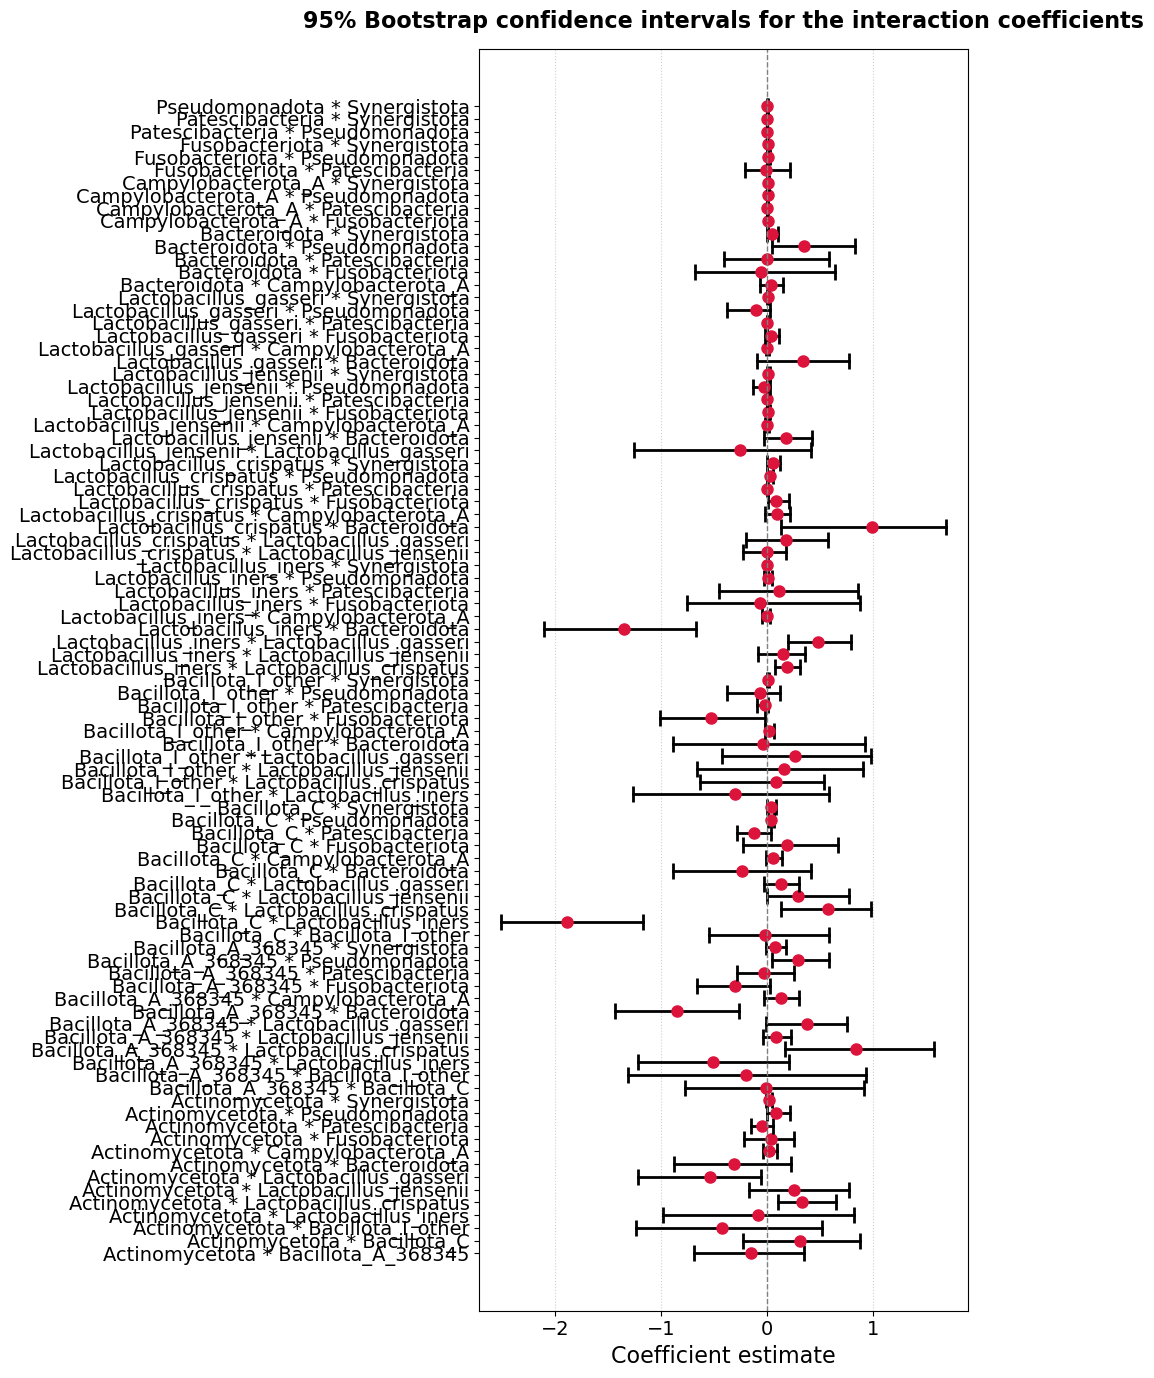

In [12]:
linear_params_df = results_df.iloc[14:, 1]   # boot_mean column
ci_lower_df = results_df.iloc[14:, 3]        # ci_lower_95 column
ci_upper_df = results_df.iloc[14:, 4]        # ci_upper_95 column

interaction_names = [
    f"{linear_feature_names[i]} * {linear_feature_names[j]}"
    for i, j in combinations(range(14), 2)
]

fig = plot_quadratic_coefficients_ridge_like_linear(linear_params_df, ci_lower_df, ci_upper_df, interaction_names)

# fig.savefig(
#     "quadratic_coeffs_ridge_corrected_14species.pdf",
#     dpi=1000,
#     bbox_inches="tight"
# )

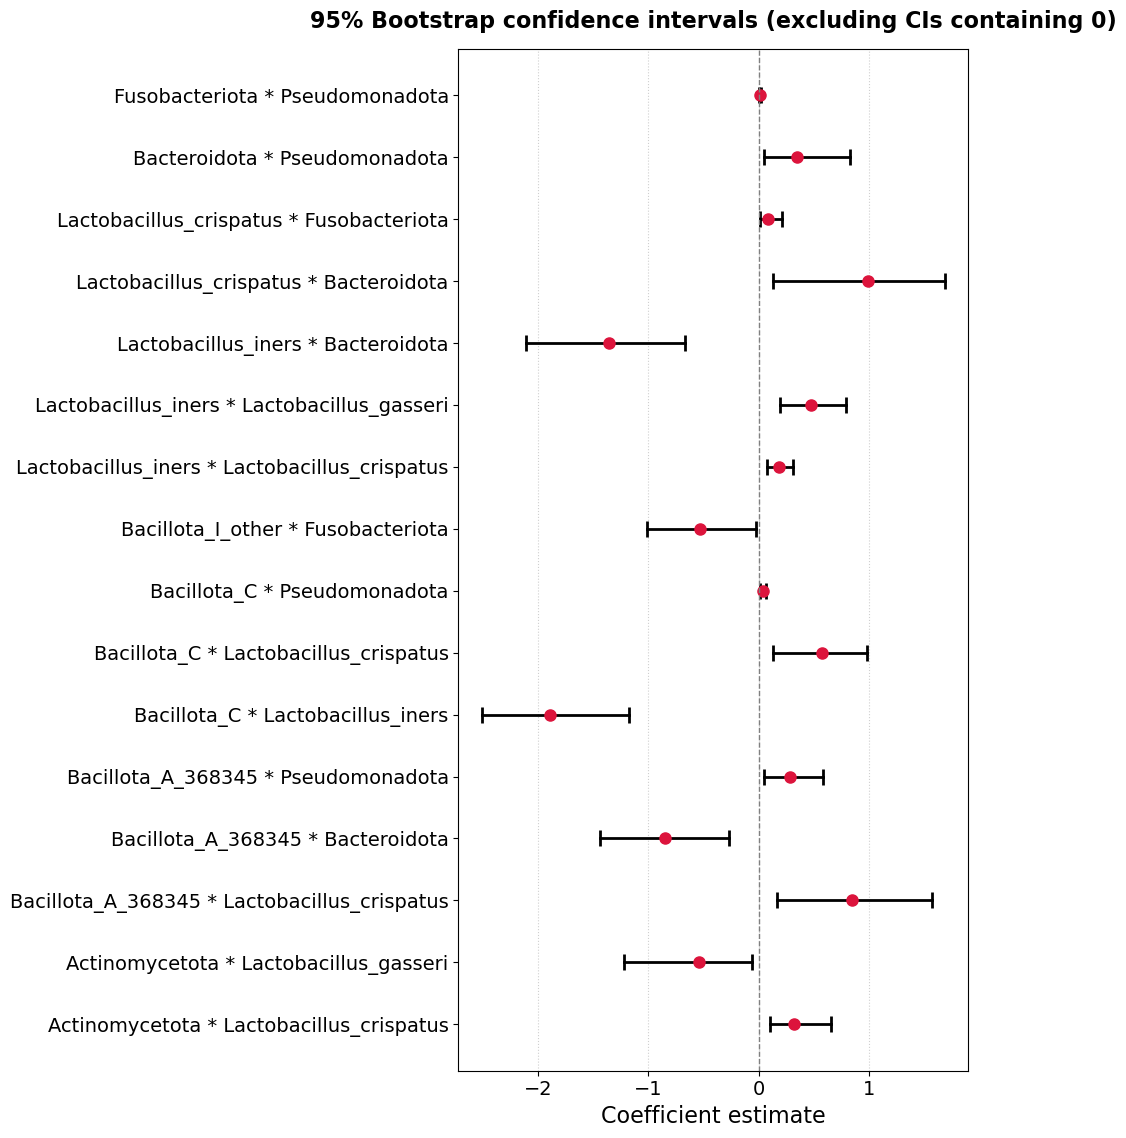

In [13]:
fig = plot_quadratic_coefficients_ridge_like_linear_filtered(linear_params_df, ci_lower_df, ci_upper_df, interaction_names)
# fig.savefig(
#     "quadratic_coeffs_ridge_corrected_14species_filtered.pdf",
#     dpi=1000,
#     bbox_inches="tight"
# )

# Figure 3

In [14]:
# Some needed functions:

def compute_full_interaction_term(X, model):
    """
    Computes the full interaction contribution:
      sum_{i<j} beta_ij * (x_i x_j )
    
    Returns: vector of shape (n_samples,)
    """

    p = X.shape[1]
    coef = model.coef_

    # split coefficients
    beta_Q = coef[p:]   # interaction coefficients only

    # build interaction features
    cross_terms = []
    for i, j in combinations(range(p), 2):
        interaction =  (X.iloc[:, i] * X.iloc[:, j]).values.reshape(-1, 1)
        cross_terms.append(interaction)

    Q = np.hstack(cross_terms)   # [n_samples, n_interactions]

    # full interaction contribution
    interaction_part = Q @ beta_Q   # shape: (n_samples,)

    return interaction_part

def predict_from_row_raw(model, X_row):

    # Build replicator features
    X_rep = construct_replicator_features(X_row)

    # Predict transformed value
    y_pred_transformed = model.predict(X_rep)
    return y_pred_transformed

def predict_from_row_transformed(model, X_row, N0=4.5, c=4):

    # Build replicator features
    X_rep = construct_replicator_features(X_row)

    # Predict transformed value
    y_pred_transformed = model.predict(X_rep)

    # Convert transformed prediction back to N
    N_pred = 10 + c - (10 - N0 + c) / np.exp(y_pred_transformed)

    # Find closest level (using your scale)
    closest_label = min([15, 50, 85], key=lambda x: abs(x - 10 * N_pred))

    # Convert to category
    if closest_label == 15:
        return "0-3"
    elif closest_label == 50:
        return "4-6"
    else:  # 85
        return "7-10"

In [15]:
interaction_term = compute_full_interaction_term(X_freq, model)

In [16]:
df = X_freq.copy()
df["interaction"] = interaction_term
df["Community_group"] = data["Community groupc "].to_numpy()
df["Nugent"] = data["Nugent score"].to_numpy()
df["Nugent_group"] = pd.cut(
    df["Nugent"],
    bins=[-np.inf, 3, 6, np.inf],
    labels=[1, 2, 3],
).astype(int)

group_map = {"I": 1, "II": 2, "III": 3, "IV": 4, "V": 5}
df["group_num"] = df["Community_group"].map(group_map)

df = df.sort_values(
    ["group_num", "Nugent_group", "interaction"],
    ascending=[True, True, False]
).reset_index(drop=True)

In [17]:
df = X_freq.copy()

# Add metadata positionally
df["interaction"] = np.asarray(interaction_term)
df["Community_group"] = data["Community groupc "].to_numpy()
df["Nugent"] = data["Nugent score"].to_numpy()

# CST ordering
group_map = {
    "I": 1,
    "II": 2,
    "III": 3,
    "IV": 4,
    "V": 5,
}

df["group_num"] = df["Community_group"].map(group_map)

# Nugent categories:
# 0–3 = 1, 4–6 = 2, 7–10 = 3
df["Nugent_group"] = pd.cut(
    df["Nugent"],
    bins=[-np.inf, 3, 6, np.inf],
    labels=[1, 2, 3],
).astype(int)

# Sort first by CST, then Nugent category,
# then interaction within each CST/Nugent block
df = (
    df.sort_values(
        by=["group_num", "Nugent_group", "interaction"],
        ascending=[True, True, False],
    )
    .reset_index(drop=True)
)

# Recover the abundance matrix in exactly the same sorted order
X_freq_sorted = df[X_freq.columns].copy()

In [18]:
predictions = []
X_sorted = df[X_freq.columns]

for i in range(len(X_freq)):
    pred = predict_from_row_raw(model, X_sorted.iloc[[i]])  # one row at a time
    predictions.append(pred[0])

predictions_transformed = []
X_sorted = df[X_freq.columns]

for i in range(len(X_freq)):
    pred = predict_from_row_transformed(model, X_sorted.iloc[[i]])  # one row at a time
    predictions_transformed.append(pred[0])

In [19]:
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
    "legend.title_fontsize": 20})

/var/folders/0g/6n85dcys0s9gtyx9gpd854pw0000gn/T/ipykernel_1200/97241493.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(


Figure saved to summary_color_code_2_2_last_version_14taxa.pdf


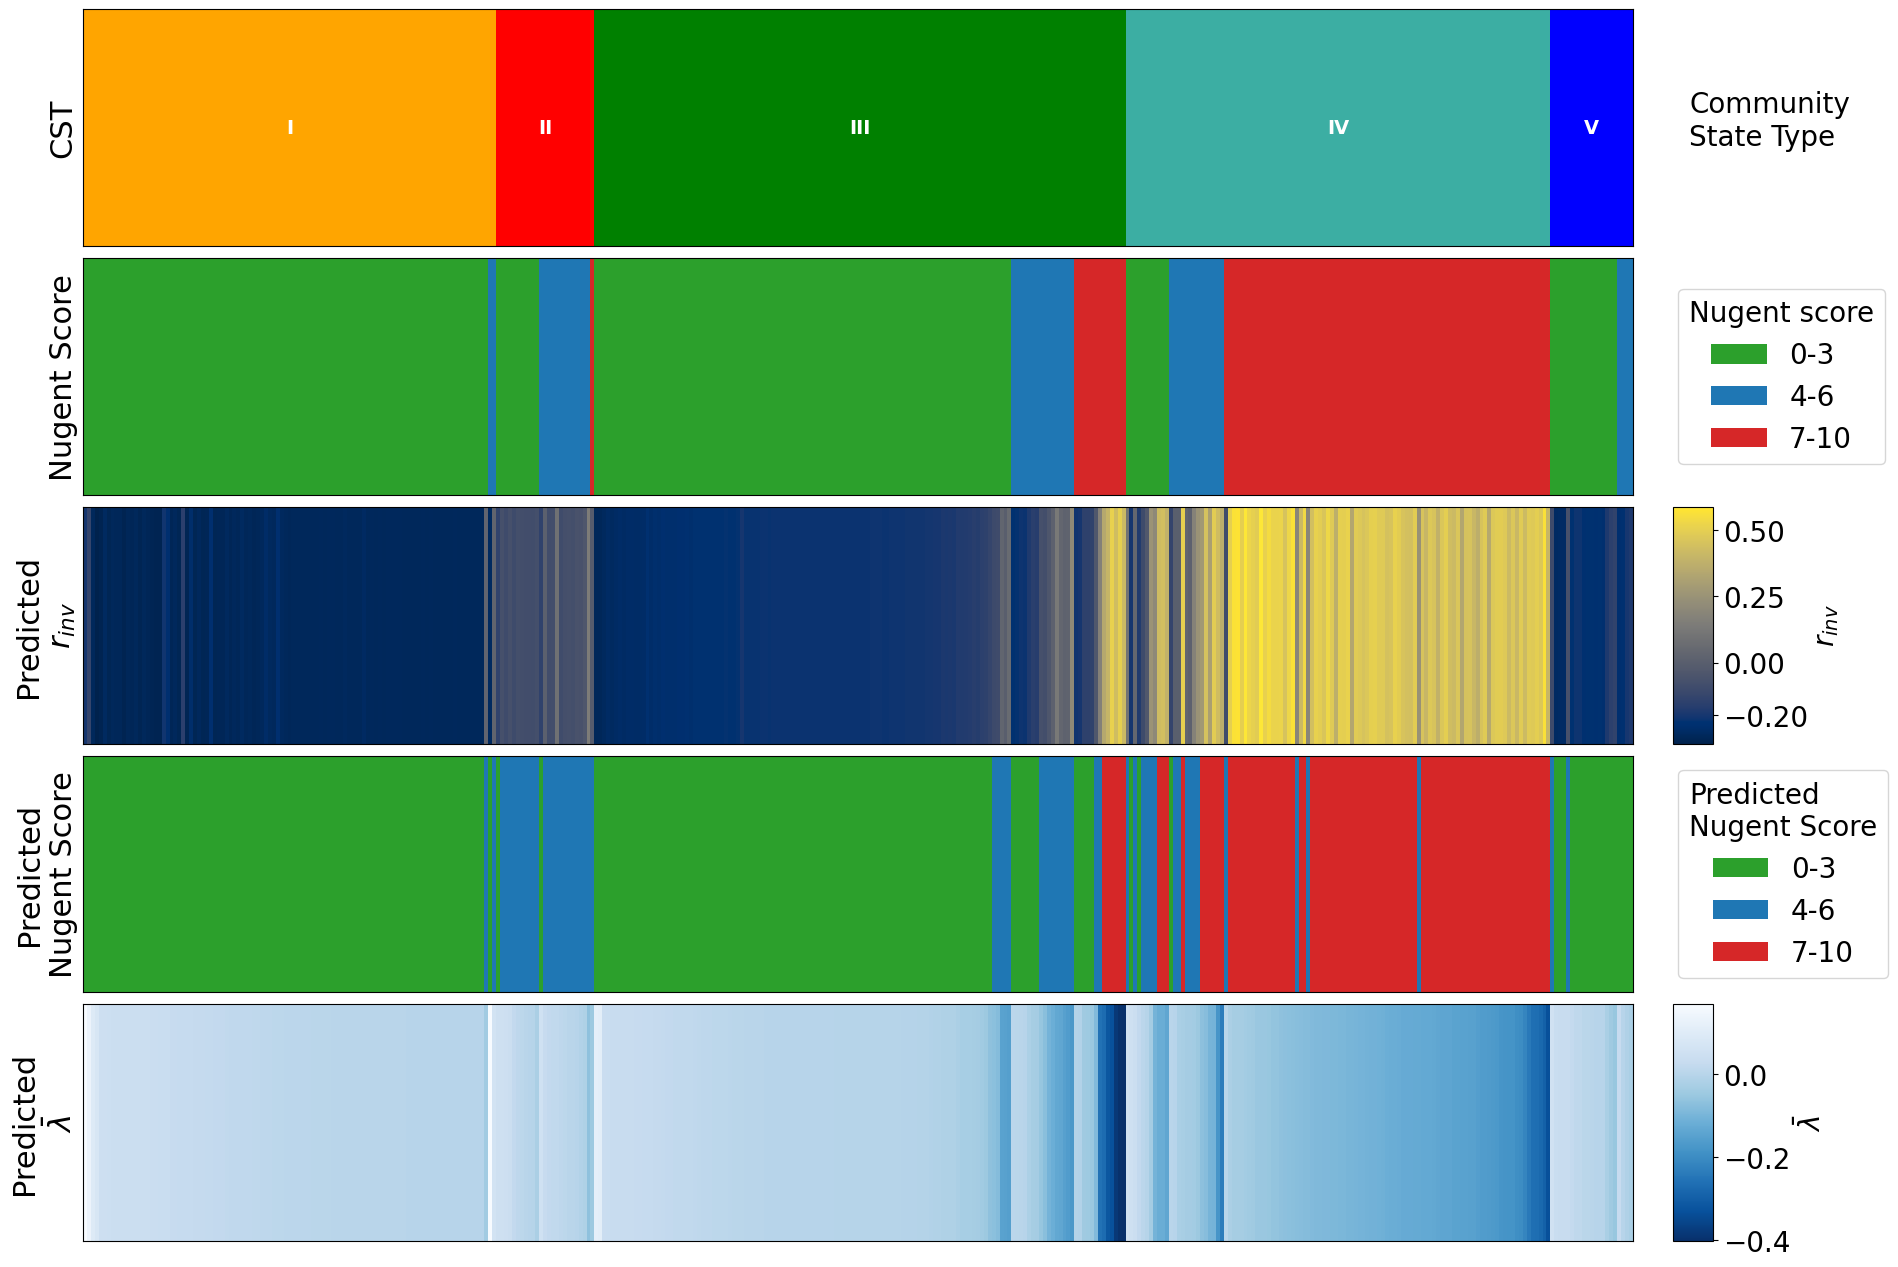

In [20]:
def plot_community_nugent_interaction_with_predictions_both(df, predictions, predictions_transformed, filename=None):
    x = np.arange(len(df))
    
    interaction = df["interaction"].values
    group_num = df["group_num"].values
    nugent = df["Nugent"].values
    predictions = np.array(predictions)
    predictions_transformed = np.array(predictions_transformed)
    
    # --- Create figure and axes ---
    fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(
        5, 1, figsize=(20, 16),
        sharex=True,
        gridspec_kw={"height_ratios": [1, 1, 1, 1, 1], "hspace": 0.05}
    )
    
    # --- Community group ---
    cmap_groups = ListedColormap(["orange", "red", "green", "#3caea3", "blue"])
    bounds = [0.5,1.5,2.5,3.5,4.5,5.5]
    norm_groups = BoundaryNorm(bounds, cmap_groups.N)
    ax1.imshow(group_num.reshape(1, -1), aspect="auto",
               cmap=cmap_groups, norm=norm_groups)
    ax1.set_yticks([])
    ax1.set_ylabel("CST", fontsize=22)
    for i in range(1,6):
        mask = group_num == i
        if mask.any():
            center = np.where(mask)[0].mean()
            ax1.text(center, 0, ["I","II","III","IV","V"][i-1],
                     ha="center", va="center", color="white",  fontweight="bold")
    legend_elements = [Patch(facecolor=cmap_groups(i), label=l)
                       for i,l in zip(range(5), ["I","II","III","IV","V"])]
    #ax1.legend(handles=legend_elements, title="Community group",
     #          loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=22)

    
    ax1.legend(
        title="Community\nState Type",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False
    )

    # --- Nugent score groups ---
    nugent_bins = [0, 3, 6, 10]
    nugent_colors = ["#2ca02c", "#1f77b4", "#d62728"]  # Green, Blue, Red
    nugent_digitized = np.digitize(nugent, nugent_bins, right=True) - 1
    cmap_nugent = ListedColormap(nugent_colors)
    norm_nugent = BoundaryNorm([0,1,2,3], cmap_nugent.N)
    
    ax2.imshow(nugent_digitized.reshape(1, -1), aspect="auto",
               cmap=cmap_nugent, norm=norm_nugent)
    ax2.set_yticks([])
    ax2.set_ylabel("Nugent Score", fontsize=22)
    legend_nugent = [Patch(facecolor=color, label=label)
                     for color, label in zip(nugent_colors, ["0-3", "4-6", "7-10"])]
    ax2.legend(handles=legend_nugent, title="Nugent score",
               loc="center left", bbox_to_anchor=(1.02, 0.5))


    
    im3 = ax3.imshow(predictions.reshape(1, -1), aspect="auto", cmap="cividis")
    ax3.set_yticks([])
    ax3.set_ylabel("Predicted\n$r_{inv}$", fontsize=22)
    
    cbar_ax3 = fig.add_axes([0.92, ax3.get_position().y0, 0.02, ax3.get_position().height])
    cbar3 = fig.colorbar(im3, cax=cbar_ax3)
    cbar3.set_ticks([-0.2, 0 , 0.25, 0.5])
    cbar3.set_label("$r_{inv}$")
    
    # --- Transformed Predictions (binned like Nugent) ---
    pred_trans_digitized = np.digitize(predictions_transformed, nugent_bins, right=True) - 1
    im4 = ax4.imshow(pred_trans_digitized.reshape(1, -1),
                     aspect="auto",
                     cmap=cmap_nugent, norm=norm_nugent,
                    alpha=1)
    ax4.set_yticks([])
    ax4.set_ylabel("Predicted\nNugent Score", fontsize=22)
    legend_pred_trans = [Patch(facecolor=color, label=label)
                         for color, label in zip(nugent_colors, ["0-3", "4-6", "7-10"])]
    ax4.legend(handles=legend_pred_trans, title="Predicted\nNugent Score",
               loc="center left", bbox_to_anchor=(1.02, 0.5))

    
    # --- Interaction ---
    im5 = ax5.imshow(interaction.reshape(1, -1), aspect="auto", cmap="Blues_r")
    ax5.set_yticks([])
    ax5.set_ylabel("Predicted\n$\\bar{\\lambda}$", fontsize=22)

    # Create separate axes on the right for the vertical colorbar
    cbar_ax5 = fig.add_axes([0.92, ax5.get_position().y0, 0.02, ax5.get_position().height])
    cbar5 = fig.colorbar(im5, cax=cbar_ax5)
    cbar5.set_label("$\\bar{\\lambda}$")
    
    #ax1.set_title("Community – Nugent – Interaction – Prediction – Prediction Transformed")

    


    for ax in [ax1, ax2, ax3, ax4, ax5]:
        ax.set_xticks([])  # removes tick marks
        ax.set_xticklabels([])  # removes any labels

    if filename is not None:
        plt.savefig(filename, bbox_inches='tight')  
        print(f"Figure saved to {filename}")

    plt.show()

plot_community_nugent_interaction_with_predictions_both(df, predictions, predictions_transformed)

## Figure S8 Boxplots to see CST specific variation

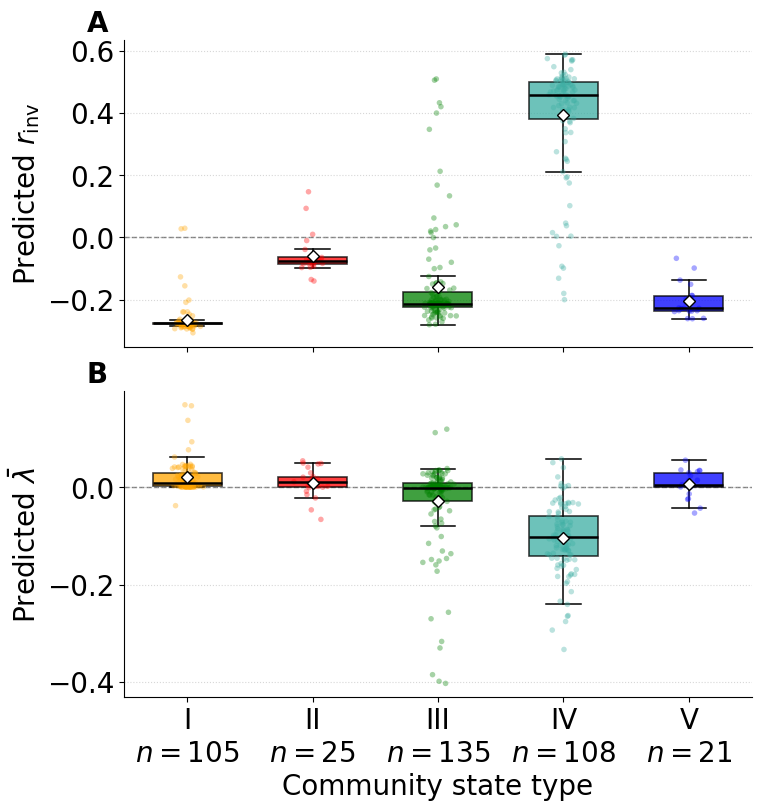

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# ------------------------------------------------------------
# Add predictions to the sorted dataframe
# ------------------------------------------------------------
df_plot = df.copy()

df_plot["r_inv"] = np.asarray(predictions).squeeze()
df_plot["r_inv_transformed"] = np.asarray(
    predictions_transformed
).squeeze()

# Choose which prediction to plot
r_inv_column = "r_inv"
# r_inv_column = "r_inv_transformed"


# ------------------------------------------------------------
# CST ordering and colors
# ------------------------------------------------------------
cst_order = ["I", "II", "III", "IV", "V"]

cst_order = [
    cst
    for cst in cst_order
    if cst in df_plot["Community_group"].dropna().unique()
]

cmap_groups = ListedColormap(
    ["orange", "red", "green", "#3caea3", "blue"]
)

# Match colors to the CSTs retained in cst_order
all_cst_colors = dict(
    zip(
        ["I", "II", "III", "IV", "V"],
        cmap_groups.colors,
    )
)

cst_colors = [
    all_cst_colors[cst]
    for cst in cst_order
]

rng = np.random.default_rng(42)


# ------------------------------------------------------------
# Plotting function
# ------------------------------------------------------------
def boxplot_by_cst(
    ax,
    dataframe,
    value_column,
    ylabel,
    panel_label,
    show_xlabels=True,
    zero_line=True,
):
    values_by_cst = [
        dataframe.loc[
            dataframe["Community_group"] == cst,
            value_column,
        ]
        .dropna()
        .to_numpy()
        for cst in cst_order
    ]

    positions = np.arange(1, len(cst_order) + 1)

    box = ax.boxplot(
        values_by_cst,
        positions=positions,
        widths=0.55,
        patch_artist=True,
        showfliers=False,
        showmeans=True,
        medianprops={
            "color": "black",
            "linewidth": 1.8,
        },
        meanprops={
            "marker": "D",
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markersize": 6,
        },
        whiskerprops={
            "color": "black",
            "linewidth": 1.1,
        },
        capprops={
            "color": "black",
            "linewidth": 1.1,
        },
    )

    # CST-specific box colors
    for patch, color in zip(
        box["boxes"],
        cst_colors,
    ):
        patch.set_facecolor(color)
        patch.set_edgecolor("black")
        patch.set_linewidth(1.2)
        patch.set_alpha(0.75)

    # Jittered observations with matching CST colors
    for position, values, color in zip(
        positions,
        values_by_cst,
        cst_colors,
    ):
        jitter = rng.normal(
            loc=0,
            scale=0.05,
            size=len(values),
        )

        ax.scatter(
            position + jitter,
            values,
            s=16,
            color=color,
            alpha=0.35,
            edgecolors="none",
            zorder=2,
        )

    if zero_line:
        ax.axhline(
            0,
            color="gray",
            linestyle="--",
            linewidth=1,
            zorder=0,
        )

    ax.set_ylabel(
        ylabel,
    )

    # Panel label
    ax.text(
        -0.06,
        1.1,
        panel_label,
        transform=ax.transAxes,
        fontsize=20,
        fontweight="bold",
        va="top",
        ha="left",
    )

    ax.grid(
        axis="y",
        linestyle=":",
        linewidth=0.8,
        alpha=0.5,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_xticks(positions)
    ax.tick_params(
        axis="both",
    )

    if show_xlabels:
        labels = [
            f"{cst}\n$n={len(values)}$"
            for cst, values in zip(
                cst_order,
                values_by_cst,
            )
        ]

        ax.set_xticklabels(labels)

        ax.set_xlabel(
            "Community state type",
        )
    else:
        ax.tick_params(
            axis="x",
            labelbottom=False,
        )


# ------------------------------------------------------------
# Vertical figure with shared CST axis
# ------------------------------------------------------------
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(7.5, 8),
    sharex=True,
    constrained_layout=True,
)

boxplot_by_cst(
    ax=axes[0],
    dataframe=df_plot,
    value_column=r_inv_column,
    ylabel=r"Predicted $r_{\mathrm{inv}}$",
    panel_label="A",
    show_xlabels=False,
)

boxplot_by_cst(
    ax=axes[1],
    dataframe=df_plot,
    value_column="interaction",
    ylabel=r"Predicted $\bar{\lambda}$",
    panel_label="B",
    show_xlabels=True,
)

plt.show()


# Optional
fig.savefig(
    "r_inv_interactions_by_CST.pdf",
    bbox_inches="tight",
)

# Figure S2

In [21]:
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 24,
    "axes.titlesize": 24,
    "axes.labelsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
})

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap, BoundaryNorm, LogNorm
from matplotlib.patches import Patch


def plot_species_with_cst_nugent_log(
    X_freq,
    df,
    species_names=None,
    filename=None,
    eps=1e-6,
):
    

    # =========================
    # Validate inputs
    # =========================
    if len(X_freq) != len(df):
        raise ValueError(
            f"X_freq has {len(X_freq)} rows, "
            f"while df has {len(df)} rows."
        )

    required_columns = [
        "group_num",
        "Nugent",
        "interaction",
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"df is missing the following columns: "
            f"{missing_columns}"
        )

    if species_names is None:
        species_names = X_freq.columns.tolist()

    missing_species = [
        species
        for species in species_names
        if species not in X_freq.columns
    ]

    if missing_species:
        raise ValueError(
            f"These species columns are missing from X_freq: "
            f"{missing_species}"
        )

    # =========================
    # Combine data
    # =========================
    plot_data = (
        X_freq[species_names]
        .reset_index(drop=True)
        .copy()
    )

    plot_data["group_num"] = (
        df["group_num"]
        .reset_index(drop=True)
        .to_numpy()
    )

    plot_data["Nugent"] = (
        df["Nugent"]
        .reset_index(drop=True)
        .to_numpy()
    )

    plot_data["interaction"] = (
        df["interaction"]
        .reset_index(drop=True)
        .to_numpy()
    )

    # Nugent categories:
    # 0 = 0–3
    # 1 = 4–6
    # 2 = 7–10
    plot_data["Nugent_group"] = pd.cut(
        plot_data["Nugent"],
        bins=[-np.inf, 3, 6, np.inf],
        labels=[0, 1, 2],
    ).astype(int)

    # Sort all columns together
    plot_data = (
        plot_data.sort_values(
            [
                "group_num",
                "Nugent_group",
                "interaction",
            ],
            ascending=[
                True,
                True,
                False,
            ],
        )
        .reset_index(drop=True)
    )

    # =========================
    # Extract sorted arrays
    # =========================
    freq_matrix = (
        plot_data[species_names]
        .to_numpy()
        .T
    )

    freq_matrix_safe = freq_matrix + eps

    group_num = (
        plot_data["group_num"]
        .to_numpy()
    )

    nugent_digitized = (
        plot_data["Nugent_group"]
        .to_numpy()
    )

    n_species, n_samples = freq_matrix.shape
    total_rows = 2 + n_species

    # =========================
    # Figure
    # =========================
    fig, ax = plt.subplots(
        figsize=(22, 16)
    )

    # =========================
    # CST colours
    # =========================
    cmap_groups = ListedColormap(
        [
            "orange",
            "red",
            "green",
            "#3caea3",
            "blue",
        ]
    )

    norm_groups = BoundaryNorm(
        [
            0.5,
            1.5,
            2.5,
            3.5,
            4.5,
            5.5,
        ],
        cmap_groups.N,
    )

    # =========================
    # Nugent colours
    # =========================
    nugent_colors = [
        "#2ca02c",
        "#1f77b4",
        "#d62728",
    ]

    cmap_nugent = ListedColormap(
        nugent_colors
    )

    norm_nugent = BoundaryNorm(
        [
            -0.5,
            0.5,
            1.5,
            2.5,
        ],
        cmap_nugent.N,
    )

    # =========================
    # Plot CST row
    # =========================
    ax.imshow(
        group_num.reshape(1, -1),
        aspect="auto",
        cmap=cmap_groups,
        norm=norm_groups,
        extent=[
            0,
            n_samples,
            0,
            1,
        ],
        origin="lower",
    )

    # =========================
    # Plot Nugent row
    # =========================
    ax.imshow(
        nugent_digitized.reshape(1, -1),
        aspect="auto",
        cmap=cmap_nugent,
        norm=norm_nugent,
        extent=[
            0,
            n_samples,
            1,
            2,
        ],
        origin="lower",
    )

    # =========================
    # Plot abundance rows
    # =========================
    species_vmin = 1e-3

    im = ax.imshow(
        freq_matrix_safe,
        aspect="auto",
        cmap="viridis",
        norm=LogNorm(
            vmin=species_vmin,
            vmax=1,
            clip=True,
        ),
        extent=[
            0,
            n_samples,
            2,
            2 + n_species,
        ],
        origin="lower",
    )

    # =========================
    # Axis labels
    # =========================
    y_labels = [
        "CST",
        "Nugent Score",
    ] + species_names

    y_ticks = (
        np.arange(total_rows) + 0.5
    )

    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_labels)

    ax.set_xticks([])
    ax.set_xlabel("Samples")

    ax.set_xlim(0, n_samples)
    ax.set_ylim(0, total_rows)

    ax.set_title(
        "Microbiota Composition - Nugent Scores - CST",
        pad=20,
    )

    # =========================
    # CST Roman numerals
    # =========================
    roman = [
        "I",
        "II",
        "III",
        "IV",
        "V",
    ]

    for i in range(1, 6):
        positions = np.flatnonzero(
            group_num == i
        )

        if len(positions) > 0:
            center = (
                positions.mean() + 0.5
            )

            ax.text(
                center,
                0.62,
                roman[i - 1],
                ha="center",
                va="center",
                color="white",
                fontweight="bold",
            )

    # =========================
    # Styling
    # =========================
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Leave space for the colour bar
    # and legend on the right.
    fig.subplots_adjust(
        left=0.16,
        right=0.84,
        bottom=0.08,
        top=0.92,
    )

    # Get the final main-axis position
    ax_position = ax.get_position()

    # =========================
    # Short species colour bar
    # =========================
    cbar_height = (
        0.6 * ax_position.height
    )

    cbar_width = 0.012
    right_gap = 0.025

    cbar_x = (
        ax_position.x1 + right_gap
    )

    cbar_y = (
        ax_position.y1 - cbar_height
    )

    cbar_ax = fig.add_axes(
        [
            cbar_x,
            cbar_y,
            cbar_width,
            cbar_height,
        ]
    )

    cbar = fig.colorbar(
        im,
        cax=cbar_ax,
    )

    cbar.set_label(
        r"Relative abundance ($\log_{10}$ scale)",
        labelpad=10,
    )

    cbar.set_ticks(
        [
            1e-3,
            1e-2,
            1e-1,
            1,
        ]
    )

    cbar.set_ticklabels(
        [
            r"$10^{-3}$",
            r"$10^{-2}$",
            r"$10^{-1}$",
            r"$1$",
        ]
    )

    # =========================
    # Nugent legend below bar
    # =========================
    legend_nugent = [
        Patch(
            facecolor=color,
            edgecolor="none",
            label=label,
        )
        for color, label in zip(
            nugent_colors,
            [
                "0–3",
                "4–6",
                "7–10",
            ],
        )
    ]

    ax.legend(
        handles=legend_nugent,
        title="Nugent score",
        loc="upper left",
        bbox_to_anchor=(
            1.025,
            0.2,
        ),
        frameon=False,
        borderaxespad=0,
    )

    # =========================
    # Save
    # =========================
    if filename is not None:
        fig.savefig(
            filename,
            bbox_inches="tight",
            dpi=300,
        )

        print(
            f"Figure saved to {filename}"
        )

    plt.show()

In [23]:
df = pd.DataFrame({
    "interaction": np.asarray(interaction_term),
    "Community_group": data["Community groupc "].to_numpy(),
    "Nugent": data["Nugent score"].to_numpy(),
})

group_map = {
    "I": 1,
    "II": 2,
    "III": 3,
    "IV": 4,
    "V": 5,
}

df["group_num"] = df["Community_group"].map(group_map)

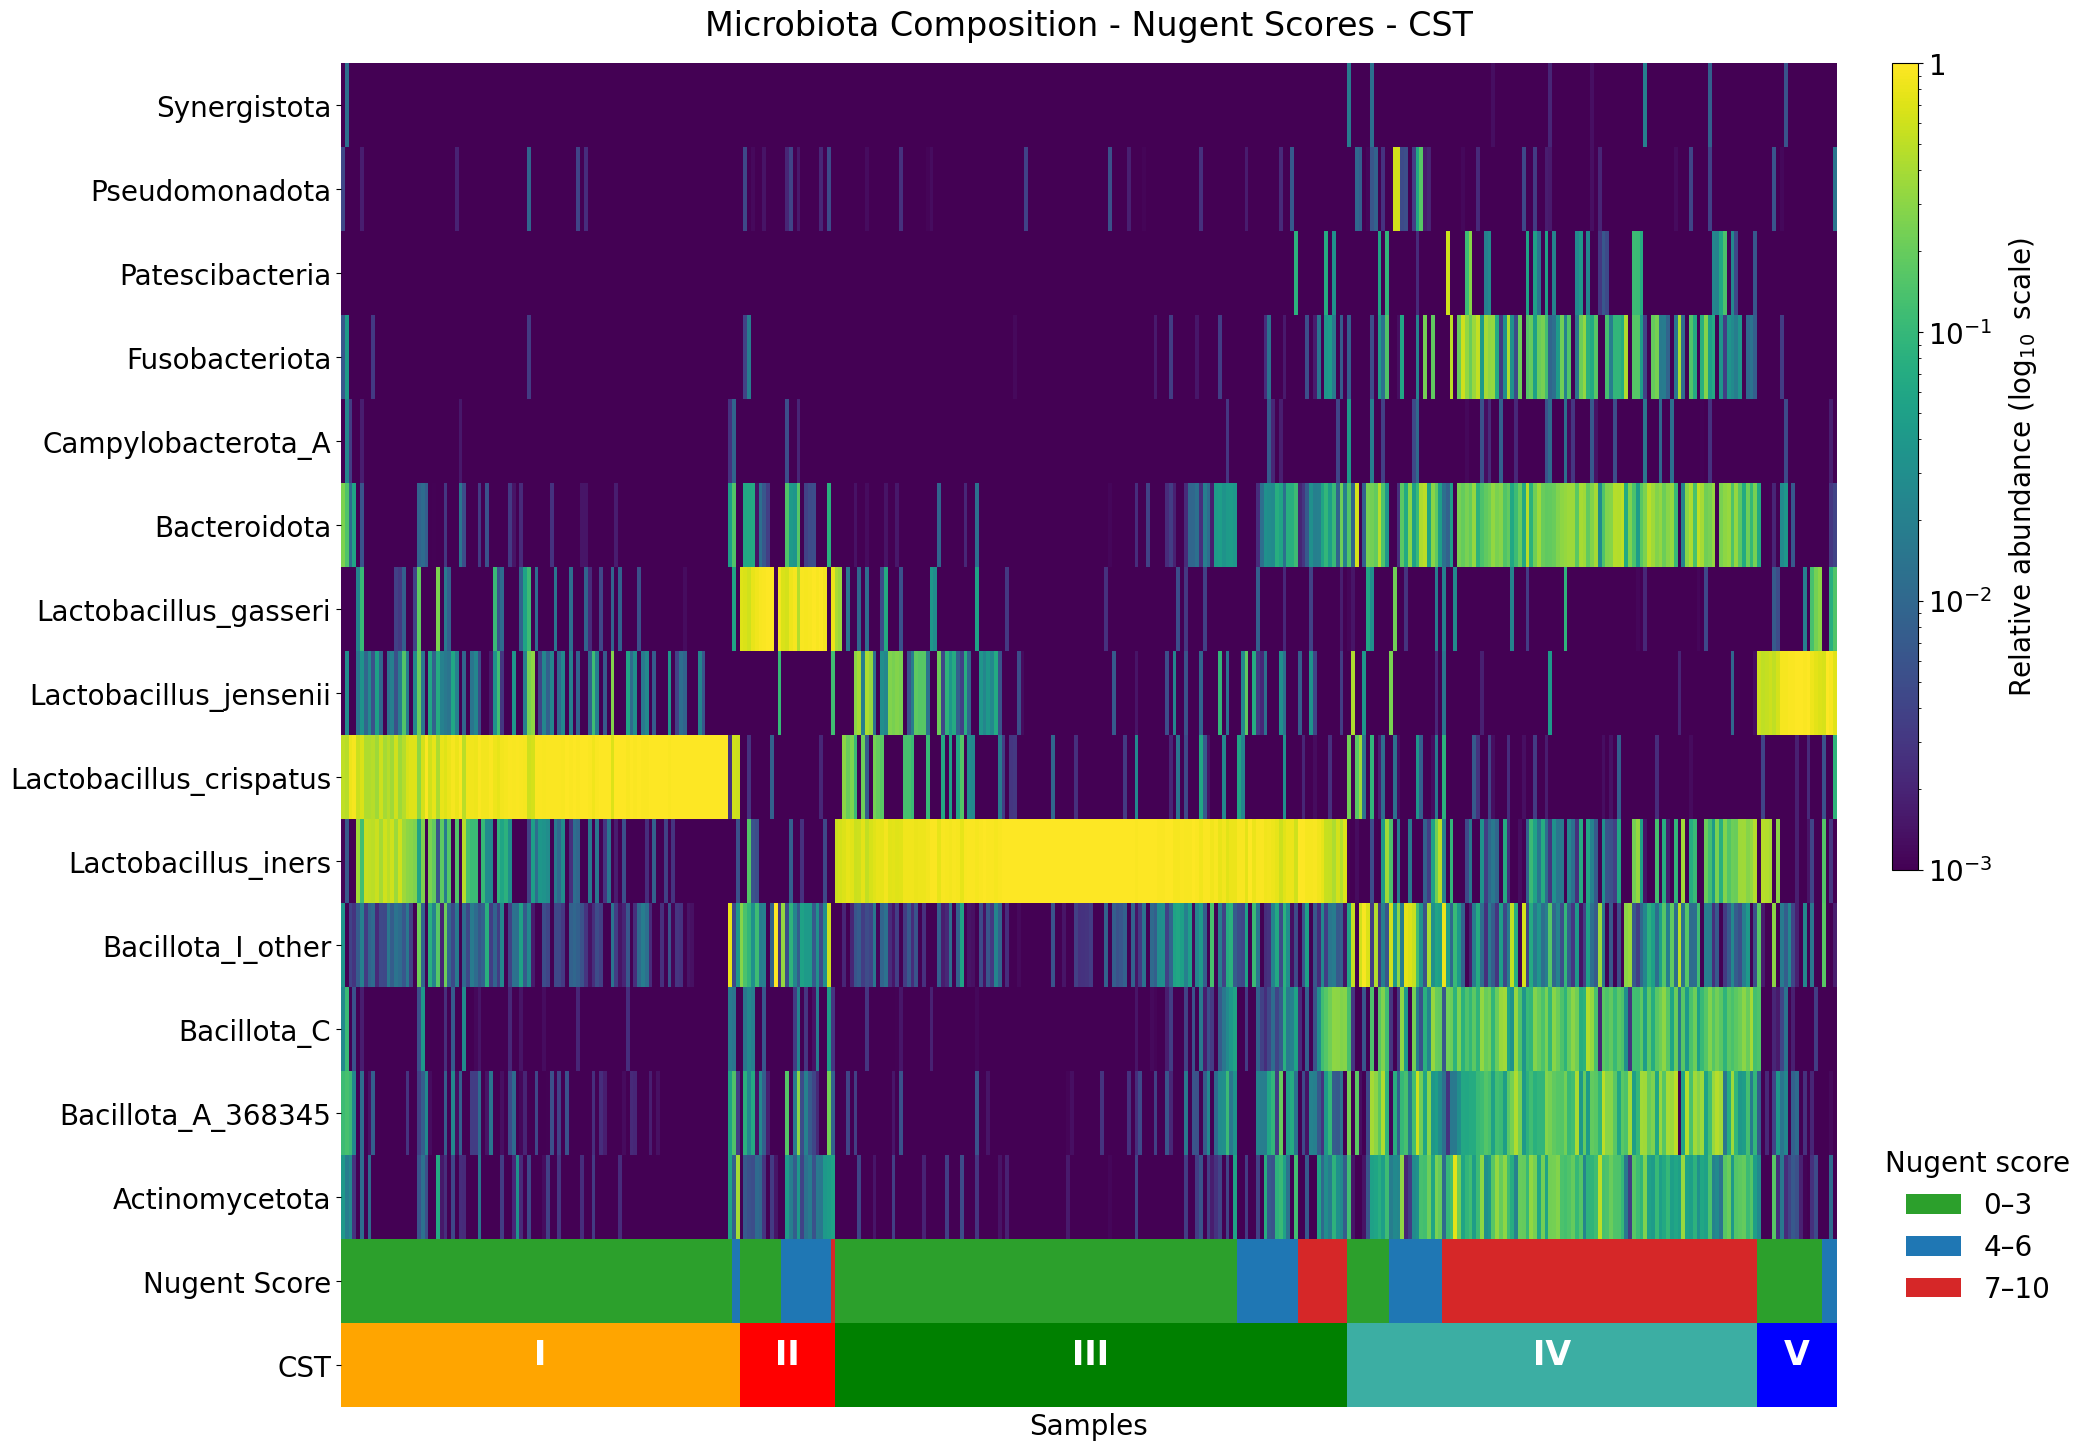

In [24]:
plot_species_with_cst_nugent_log(
    X_freq=X_freq,
    df=df,
    species_names=X_freq.columns.tolist(),
)

# Figure S3

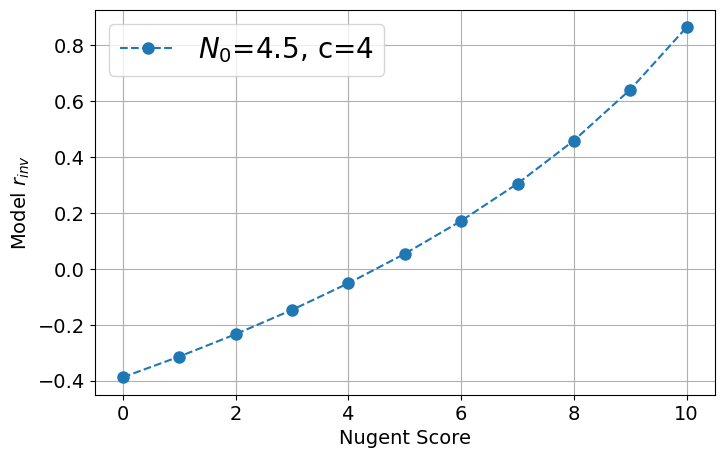

In [145]:
def transform_y(y, N0=None, c=None):
    if N0 is None or c is None:
        return y
    N_max = 10
    d = N_max - 2 * N0 + c
    transformed = np.log(N0 + d) - np.log(N_max - y + c)
    return transformed

# Input range
y_values = np.arange(0, 11)

# Parameters
N0 = 4.5
c=4
N_max = 10

# Compute transformed values
transformed_values = transform_y(y_values, N0=N0, c=c)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(y_values, transformed_values, marker='o', linestyle='--',markersize = 8, label=f'$N_0$={N0}, c={c}')
plt.xlabel('Nugent Score')
plt.ylabel('Model $r_{inv}$')
plt.grid(True)
plt.legend()
#plt.savefig("transformation.pdf",  bbox_inches='tight')
plt.show()

# Figure 1

In [92]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyArrowPatch, Circle
import matplotlib as mpl


def illustrate_prediction_replicator_ball(model, X_freq, index, linear_feature_names):
    # Extract the sample
    row = X_freq.iloc[index]
    predicted_label = predict_from_row(model, X_freq.iloc[[index]])[0]

    # Original health states -> Nugent score ranges
    health_to_nugent = {
        "healthy": "0-3",
        "intermediate": "4-6",
        "BV": "7-10"
    }

    nugent_states = ["0-3", "4-6", "7-10"]
    predicted_nugent = health_to_nugent[predicted_label]

    health_colors = {
        "0-3": "#E6E6E6",  # healthy
        "4-6": "#BDBDBD",  # intermediate
        "7-10": "#636363"  # BV
}




    # Taxa colors
    taxa_colors = [
        "#1f77b4", "#ff7f0e", "#2ca02c", "#17becf", "#9467bd",
        "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#d62728",
        "#393b79", "#e6550d", "#31a354", "#756bb1"
    ]

    # Invert for plotting (bottom-up)
    row_values = row[::-1]
    taxa_names = linear_feature_names[::-1]
    taxa_colors = taxa_colors[::-1]

    fig, ax = plt.subplots(figsize=(10,6))

    # Positions
    left_x = 0
    middle_x = 1.5
    right_x = 3

    # -----------------
    # Left bar: microbiota composition
    # -----------------
    bottom = 0
    bars = []
    for value, color, label in zip(row_values, taxa_colors, taxa_names):
        b = ax.bar(left_x, value, bottom=bottom, color=color, width=0.5, label=label, alpha=0.85)
        bars.append(b[0])
        bottom += value

    ax.text(
    left_x - 0.45, 0.5,
    "Microbiota composition",
    ha='center',
    va='center',
    rotation=90,
    fontsize=14,
    fontweight='bold')

    # -----------------
    # Middle: replicator model as a bigger circle
    # -----------------
    replicator_center = (middle_x, 0.5)
    replicator_radius = 0.35
    circle = Circle(
        replicator_center,
        replicator_radius,
        facecolor="#4A4A4A",   # dark neutral gray
        edgecolor="black",
        linewidth=1.2,
        alpha=0.95
    )
    ax.add_patch(circle)
    ax.text(*replicator_center, "Replicator\nModel", ha='center', va='center', fontsize=12, fontweight='bold', color='white')

    # -----------------
    # Right bar: predicted Nugent score
    # -----------------
    box_height = 1/3
    for i, state in enumerate(nugent_states):
        y = i * box_height
    
        is_pred = (state == predicted_nugent)
    
        ax.bar(
            right_x,
            box_height,
            bottom=y,
            width=0.5,
            facecolor="#B0B0B0" if is_pred else "none",
            edgecolor="black",
            linewidth=1.0
    )


    ax.text(right_x, -0.05, "Nugent Score", ha='center', va='top', fontsize=14, fontweight='bold')

    # Add state names on bars
    for i, state in enumerate(nugent_states):
        ax.text(right_x, i*(1/3) + 1/6, state, ha='center', va='center', fontsize=12, color='black')

    # -----------------
    # Curved arrows from left taxa segments into replicator
    # -----------------
    for i, value in enumerate(np.cumsum(row_values) - row_values/2):
        arrow = FancyArrowPatch(
            posA=(left_x + 0.5, value),
            posB=(middle_x - replicator_radius, replicator_center[1]),
            connectionstyle="arc3,rad=0.3",  # curved
            arrowstyle='-|>',
            mutation_scale=12,
            color='black',
            lw=1.2
        )
        ax.add_patch(arrow)

    # Curved arrow from replicator to predicted Nugent score (stop slightly before the bar)
    state_idx = nugent_states.index(predicted_nugent)
    arrow_y = state_idx * (1/3) + 1/6
    arrow = FancyArrowPatch(
        posA=(middle_x + replicator_radius, replicator_center[1]),
        posB=(right_x - 0.15, arrow_y),  # stop slightly before the bar
        connectionstyle="arc3,rad=-0.2",  # curved
        arrowstyle='-|>',
        mutation_scale=15,
        color='black',
        lw=1.5
    )
    ax.add_patch(arrow)

    # -----------------
    # Final touches
    # -----------------
    ax.set_xlim(-0.5, right_x + 0.5)
    ax.set_ylim(-0.15, 1.05)
    ax.axis('off')  # remove axes



    # Legend for microbiota
    ax.legend(bars[::-1], linear_feature_names, bbox_to_anchor=(1.05,1), loc='upper left', title="Taxa", fontsize=14)

    #ax.set_title(f'Sample {index} prediction: {predicted_nugent}', fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()
    return fig

def predict_from_row(model, X_rows, N0=4.5, c=3):
    # Build replicator features for all rows
    X_rep = construct_replicator_features(X_rows)

    # Predict transformed values
    y_pred_transformed = model.predict(X_rep)

    # Convert transformed predictions back to N
    N_pred = 10 + c - (10 - N0 + c) / np.exp(y_pred_transformed)

    # Compute closest labels
    levels = [15, 50, 85]
    output_labels = []
    
    for Np in N_pred:
        closest = min(levels, key=lambda x: abs(x - 10 * Np))
        if closest == 15:
            output_labels.append("healthy")
        elif closest == 50:
            output_labels.append("intermediate")
        else:
            output_labels.append("BV")

    return output_labels


In [93]:
plt.rcParams.update({
    "font.size": 20,          # base font size
    "axes.labelsize": 18,     # x/y labels
    "axes.titlesize": 18,     # subplot titles
    "xtick.labelsize": 16,    # x-tick labels
    "ytick.labelsize": 16,    # y-tick labels
    "legend.fontsize": 12     # legend
})

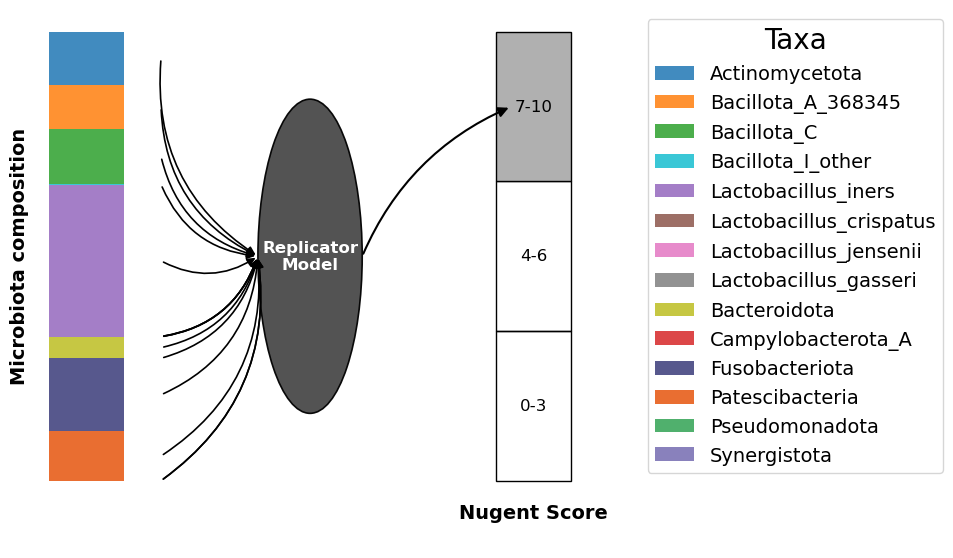

In [94]:
fig = illustrate_prediction_replicator_ball(model, X_freq, 44, linear_feature_names)

In [95]:
# Save as PDF in a separate cell
# fig.savefig("sample_44_prediction_14.pdf", dpi=1000, bbox_inches='tight')
